# Fragrance Shelf-Life Stability — Exploration & Cleaning


This notebook is the first pass: get the data into a state we can trust, then
see what it says. Nothing here assumes an answer — the fixes are applied as the
problems turn up, and each one is checked before moving on.

1. Getting to know the file
2. Normal operating range proof
3. Missing values
4. Timeline
5. Correlations and data leakage
6. Finding 8th May


## 0. Setup

Two colours do all the work: blue for normal, red for whatever turns out to be
the problem. They were checked for colour-blind separation before use.

In [1]:
import math
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

CSV = "fragrance_stability_dataset_corrupted_20260601_161558.csv"

BLUE, RED, BAND = "#2a78d6", "#d03b3b", "#cde2fb"
INK, INK2, MUTED, GRID, SURF = ("#0b0b0b", "#52514e", "#898781",
                                "#e1e0d9", "#fcfcfb")

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF,
    "savefig.facecolor": SURF, "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11.5,
    "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.labelcolor": INK2, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 1.9,
})

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

## 1. Getting to know the file

In [2]:
df = pd.read_csv(CSV, dtype={"event_timestamp": "string"},
                 low_memory=False)

print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"unique batch_id: {df['batch_id'].nunique():,}")
print(f"duplicate rows : {df.duplicated().sum()}")
df.head(4)

259,200 rows x 16 columns
unique batch_id: 259,200
duplicate rows : 0


,batch_id,event_timestamp,plant_location,plant_country,production_line_id,temp_value,temp_unit,vessel_pressure_bar,refractive_index,density_g_cm3,ph_level,mixing_torque_nm,mass_flow_rate_kg_h,stability_months,purity_grade,oxidation_risk_flag
0,BATCH-2023-000001,2023-06-02 03:05:00,Plant-05,Country-05,Fragrance-Synthesis-Reactor-02,82.3319,C,2.46575,1.465316,0.858032,NaN,11.97486,492.9606,21.090538,Industrial Grade,False
1,BATCH-2023-000002,2023-04-12 02:47:30,Plant-05,Country-05,Fragrance-Synthesis-Reactor-04,91.7391,C,2.24107,1.455938,0.876435,5.79598,11.85726,449.9237,21.202418,Industrial Grade,False
2,BATCH-2023-000003,2023-06-03 11:35:30,Plant-03,Country-03,Fragrance-Synthesis-Reactor-07,85.0281,C,2.34404,1.468787,0.848555,5.31299,12.02680,437.1050,22.515180,Industrial Grade,False
3,BATCH-2023-000004,2023-05-11 02:43:00,Plant-04,Country-04,Fragrance-Synthesis-Reactor-05,88.5994,C,2.10548,1.447880,0.871153,5.44103,11.67030,439.3516,19.843445,Technical Grade,True


Every `batch_id` is unique and there are no duplicate rows, so one row is one
batch carrying one set of sensor readings. That saves us a decision: no
aggregation per batch is needed, and every row is an independent observation.

Ten columns are numeric measurements and identifiers; the rest are labels.

In [3]:
df.dtypes.to_frame("dtype").T

,batch_id,event_timestamp,plant_location,plant_country,production_line_id,temp_value,temp_unit,vessel_pressure_bar,refractive_index,density_g_cm3,ph_level,mixing_torque_nm,mass_flow_rate_kg_h,stability_months,purity_grade,oxidation_risk_flag
dtype,object,string[python],object,object,object,float64,object,float64,float64,float64,float64,float64,float64,float64,object,bool


## 2.  Normal operating range proof

The use-case statement gives a normal operating range for each sensor, so the
quickest sanity check is to put the observed range next to the expected one.

In [4]:
SPEC = {
    "temp_value": (75, 100), "vessel_pressure_bar": (2, 3),
    "refractive_index": (1.43, 1.49), "density_g_cm3": (0.80, 0.90),
    "ph_level": (5.0, 6.0), "mixing_torque_nm": (9, 12.5),
    "mass_flow_rate_kg_h": (380, 520),
}

check = df[list(SPEC)].agg(["min", "max", "mean", "std"]).T
check["expected"] = [f"{lo} - {hi}" for lo, hi in SPEC.values()]
check.round(4)

,min,max,mean,std,expected
temp_value,78.9556,410.0000,86.8795,10.8545,75 - 100
vessel_pressure_bar,-1.0000,2.6196,2.3003,0.2325,2 - 3
refractive_index,1.4372,1.4837,1.4607,0.0117,1.43 - 1.49
density_g_cm3,0.8372,860.0000,2.8900,41.7127,0.8 - 0.9
ph_level,4.9451,14.0000,5.5226,0.5001,5.0 - 6.0
mixing_torque_nm,10.0352,12.5645,11.9410,0.3925,9 - 12.5
mass_flow_rate_kg_h,383.2505,521.9248,453.5587,36.8974,380 - 520


Four of these cannot be real. Pressure reaching **−1 bar** when the statement
says it cannot be negative; **pH exactly 14.0**, which is the theoretical top of
the scale; **density 860 g/cm³**, denser than any known material; and a
temperature of **410**.

Values like these are usually not measurements at all but codes written by the
acquisition system when a sensor fails. Could be?

In [5]:
for col in SPEC:
    top = df[col].value_counts().head(1)
    v, n = top.index[0], top.iloc[0]
    if n > 50:
        print(f"{col:22s} value {v:>8g} repeats {n:>4} times")

temp_value             value      210 repeats  507 times
vessel_pressure_bar    value       -1 repeats  544 times
density_g_cm3          value      860 repeats  558 times
ph_level               value       14 repeats  543 times


All four repeat hundreds of times at exactly the same number. Real measurements
do not behave like that; codes do.

Temperature is the odd one out, though: its most repeated value is **210**,
while the maximum we saw a moment ago was 410. Two different impossible numbers
in one column is worth a closer look.

In [6]:
print(df["temp_unit"].value_counts(dropna=False).to_string())
print()
print(df.groupby("temp_unit")["temp_value"].agg(
    ["count", "mean", "min", "max"]).round(2).to_string())

temp_unit
C      234524
NaN     23170
F        1506

            count    mean     min    max
temp_unit                               
C          234524   86.22   78.96  210.0
F            1506  189.05  174.68  410.0


There is the explanation, and it is a different problem from the failure codes:
temperature is stored as a **value plus a unit column**, and **1,506 rows are in
Fahrenheit**. Those rows average 189, which looks like a wild outlier until you
notice it is simply not Celsius.

And the two puzzles turn out to be the same puzzle:

```
(410 °F − 32) / 1.8 = 210.0 °C     exactly
```

`210` and `410` are one failure code written in the two different units. That
also tells us the order to work in: harmonise the units first, and then a single
threshold catches the code in both.

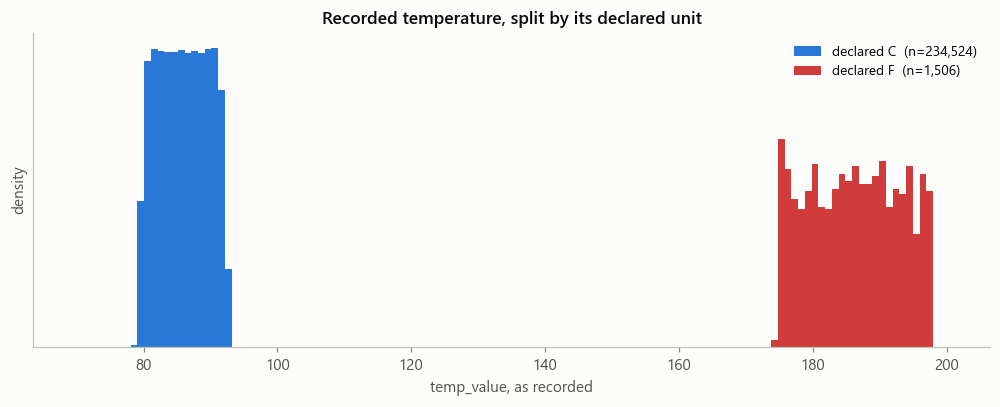

In [7]:
fig, ax = plt.subplots(figsize=(9.2, 3.8))
for unit, color in [("C", BLUE), ("F", RED)]:
    ax.hist(df.loc[df["temp_unit"] == unit, "temp_value"],
            bins=np.linspace(70, 200, 130), density=True, color=color,
            label=f"declared {unit}  (n={(df['temp_unit']==unit).sum():,})")
ax.set_xlabel("temp_value, as recorded")
ax.set_yticks([])
ax.set_ylabel("density")
ax.legend()
ax.set_title("Recorded temperature, split by its declared unit")
plt.tight_layout(); plt.show()

Two clean clusters, roughly 100 degrees apart — the signature of a unit mix
rather than a process excursion. Converting the Fahrenheit rows should drop them
straight into the same range as everything else.

In [8]:
df["temp_c"] = np.where(df["temp_unit"] == "F",
                        (df["temp_value"] - 32) / 1.8,
                        df["temp_value"])
df["temp_c"] = df["temp_c"].where(df["temp_unit"].notna())

f = df["temp_unit"] == "F"
print(f"Fahrenheit rows: {df.loc[f, 'temp_value'].mean():.1f}"
      f"  ->  {df.loc[f, 'temp_c'].mean():.1f} C")

# A value with no declared unit could not be converted at all.
print(f"values with no declared unit: "
      f"{(df['temp_value'].notna() & df['temp_unit'].isna()).sum()}")

Fahrenheit rows: 189.1  ->  87.3 C
values with no declared unit: 0


If a batch with one bad sensor is otherwise
ordinary, we empty that one cell. If such batches are systematically different,
the whole row is suspect and should be dropped.

That is testable, so let us test it instead of assuming.

In [9]:
SENSORS = ["temp_c", "vessel_pressure_bar", "refractive_index",
           "density_g_cm3", "ph_level", "mixing_torque_nm",
           "mass_flow_rate_kg_h"]
CODES = {"vessel_pressure_bar": -1.0, "ph_level": 14.0,
         "density_g_cm3": 860.0}

coded = pd.DataFrame(False, index=df.index, columns=SENSORS)
coded["temp_c"] = df["temp_c"] > 150         # 210 C and its 410 F twin
for col, code in CODES.items():
    coded[col] = df[col] == code
has_code = coded.any(axis=1)

print(f"cells holding a code: {int(coded.values.sum()):,}")
print(f"batches affected    : {int(has_code.sum()):,} "
      f"({has_code.mean() * 100:.2f}%)")

y = df["stability_months"]
print(f"\nshelf life with a code : {y[has_code].mean():.3f} months")
print(f"shelf life without one : {y[~has_code].mean():.3f} months")
print(f"difference             : "
      f"{y[has_code].mean() - y[~has_code].mean():+.3f} months")

cells holding a code: 2,171
batches affected    : 2,136 (0.82%)

shelf life with a code : 21.001 months
shelf life without one : 21.536 months
difference             : -0.535 months


Half a month lower, which is not what we wanted to see. It suggests these
batches genuinely are different, and that dropping them might be the safer call.

But a gap like that has two possible explanations: either a failed sensor goes
together with a bad batch, or the coded rows are simply not spread evenly across
the fleet. Worth checking where they land before concluding anything.

In [10]:
df.assign(coded=has_code).groupby("plant_location").agg(
    coded_pct=("coded", lambda s: s.mean() * 100),
    batches=("coded", "size")).round(3)

,coded_pct,batches
plant_location,,
Plant-01,0.000,70644
Plant-02,0.000,35140
Plant-03,0.000,48823
Plant-04,3.824,55858
Plant-05,0.000,48735


They are not spread at all. **Every code sits in Plant-04**, on 3.8% of its
batches, and the other four plants have exactly none. So the comparison above was
never coded-versus-clean — it was Plant-04 against the rest of the fleet, and
Plant-04 evidently differs for some reason we have not found yet.

Two things follow. We should park that observation, because a data-acquisition
problem confined to one site is a finding in its own right. And the honest test
is to compare *inside* Plant-04, where that confound cannot operate.

In [11]:
p4 = df[df["plant_location"] == "Plant-04"]
m4 = has_code[p4.index]
a, b = p4.loc[m4, "stability_months"], p4.loc[~m4, "stability_months"]

print(f"within Plant-04, with a code : {a.mean():.3f}  (n={len(a):,})")
print(f"within Plant-04, without one : {b.mean():.3f}  (n={len(b):,})")
print(f"difference                   : {a.mean() - b.mean():+.3f} months"
      f"  ({(a.mean() - b.mean()) / b.std():+.3f} std)")

# Per reactor too, so no single unit can be driving it.
diffs = []
for _, g in p4.groupby("production_line_id"):
    mg = has_code[g.index]
    if mg.sum() >= 30:
        diffs.append(g.loc[mg, "stability_months"].mean()
                     - g.loc[~mg, "stability_months"].mean())
diffs = pd.Series(diffs)
print(f"\nper-reactor differences: mean {diffs.mean():+.3f} months, "
      f"{(diffs < 0).sum()} of {len(diffs)} negative")

within Plant-04, with a code : 21.001  (n=2,136)
within Plant-04, without one : 21.060  (n=53,722)
difference                   : -0.059 months  (-0.026 std)

per-reactor differences: mean -0.058 months, 5 of 8 negative


So a batch with a coded reading is an ordinary batch whose instrument failed. Its
other six sensors and its lab result are perfectly good, and that settles the
question: **empty the cell, keep the row.**

In [12]:
raw_sensors = df[SENSORS].copy()     # kept for a comparison in section 5
before = df[SENSORS].agg(["mean", "std", "min", "max"]).T

for col in SENSORS:
    df[col] = df[col].mask(coded[col])

after = df[SENSORS].agg(["mean", "std", "min", "max"]).T
pd.concat([before.add_suffix(" before"),
           after.add_suffix(" after")], axis=1).round(4)

,mean before,std before,min before,max before,mean after,std after,min after,max after
temp_c,86.2300,6.9169,78.9556,210.0000,85.9535,3.6958,78.9556,93.1264
vessel_pressure_bar,2.3003,0.2325,-1.0000,2.6196,2.3080,0.1702,1.9893,2.6196
refractive_index,1.4607,0.0117,1.4372,1.4837,1.4607,0.0117,1.4372,1.4837
density_g_cm3,2.8900,41.7127,0.8372,860.0000,0.8600,0.0117,0.8372,0.8859
ph_level,5.5226,0.5001,4.9451,14.0000,5.5031,0.2910,4.9451,6.1110
mixing_torque_nm,11.9410,0.3925,10.0352,12.5645,11.9410,0.3925,10.0352,12.5645
mass_flow_rate_kg_h,453.5587,36.8974,383.2505,521.9248,453.5587,36.8974,383.2505,521.9248


Density is back to 0.860 ± 0.012 and every sensor now sits inside its declared
range. That "before" column is worth keeping in mind: any control chart built on
it would have been useless, and nothing in the data would have said so.

## 3. Missing values

Blanks now come from two different places: the gaps that arrived in the file, and
the cells we emptied ourselves. We already know those two do not behave the same
way — the codes were Plant-04 only — so it is worth keeping them apart rather
than collapsing everything into one "missing" figure.

In [13]:
gap_table = pd.DataFrame({
    "gaps in the file": (df[SENSORS].isna() & ~coded).sum(),
    "cells we emptied": coded.sum(),
    "blank in total": df[SENSORS].isna().sum(),
})
gap_table["total %"] = (gap_table["blank in total"] / len(df) * 100).round(3)
gap_table

,gaps in the file,cells we emptied,blank in total,total %
temp_c,23170,526,23696,9.142
vessel_pressure_bar,22975,544,23519,9.074
refractive_index,22971,0,22971,8.862
density_g_cm3,23043,558,23601,9.105
ph_level,22937,543,23480,9.059
mixing_torque_nm,22880,0,22880,8.827
mass_flow_rate_kg_h,23162,0,23162,8.936


The original gaps outnumber our own edits roughly forty to one, and they are
strikingly even: between 8.83% and 8.94% on every one of the seven sensors. That
evenness is informative in itself — it reads as a general recording problem
rather than one unreliable instrument. Our edits add about 0.2 points to four
sensors and nothing to the other three.

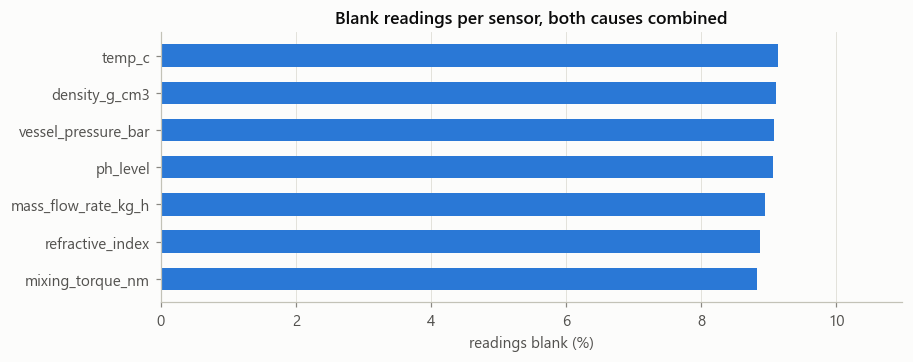

In [14]:
gaps = (df[SENSORS].isna().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(8.4, 3.4))
ax.barh(gaps.index, gaps.values, color=BLUE, height=0.6)
ax.grid(False); ax.grid(True, axis="x"); ax.set_axisbelow(True)
ax.set_xlim(0, gaps.max() * 1.2)
ax.set_xlabel("readings blank (%)")
ax.set_title("Blank readings per sensor, both causes combined")
plt.tight_layout(); plt.show()

The more useful question is how the gaps combine. If each sensor failed
independently about 9% of the time, all seven failing on the same batch should
happen roughly never.

In [15]:
n_missing = df[SENSORS].isna().sum(axis=1)
p = df[SENSORS].isna().mean().mean()

combo = n_missing.value_counts().sort_index().to_frame("batches")
combo["expected if independent"] = [
    round(len(df) * math.comb(7, k) * p**k * (1-p)**(7-k), 1)
    for k in combo.index]
combo

,batches,expected if independent
0,151958,133937.1
1,80685,92733.8
2,18625,27516.8
3,2396,4536.1
4,182,448.7
5,10,26.6
7,5344,0.0


The single and double dropouts line up with independence closely enough. The
tail does not: **5,344 batches have all seven sensors blank**, where chance
alone predicts essentially none.

So there are two different failure modes mixed together — random dropouts on
individual sensors, and total blackouts of the acquisition system. The blackout
rows carry no process information whatsoever and cannot support a prediction,
which is worth knowing before we build anything.

In [16]:
# Only the gaps that arrived in the file: our own edits are Plant-04
# only, so mixing them in would reintroduce the confound.
original = df[SENSORS].isna() & ~coded

pd.DataFrame({
    "gap %": original.mean() * 100,
    "shelf life when missing": [
        df.loc[original[c], "stability_months"].mean() for c in SENSORS],
    "shelf life when present": [
        df.loc[~original[c], "stability_months"].mean() for c in SENSORS],
    "gap rate spread across plants": [
        round(float(df.assign(m=original[c])
                    .groupby("plant_location")["m"].mean().mul(100).std()), 3)
        for c in SENSORS],
}).round(3)

,gap %,shelf life when missing,shelf life when present,gap rate spread across plants
temp_c,8.939,21.517,21.533,0.147
vessel_pressure_bar,8.864,21.521,21.533,0.148
refractive_index,8.862,21.519,21.533,0.104
density_g_cm3,8.890,21.553,21.530,0.118
ph_level,8.849,21.510,21.534,0.161
mixing_torque_nm,8.827,21.518,21.533,0.058
mass_flow_rate_kg_h,8.936,21.507,21.534,0.095


Two checks, both clean. The shelf-life columns agree to the third decimal across
all seven sensors on 259,200 rows, so the gaps do not know the outcome. And the
gap rate barely varies between plants — a spread of about 0.1 percentage points,
against the 3.8-point gulf we saw for the codes. These gaps really are
indiscriminate, which is what makes filling them defensible.

We will not fill them here, though. Any statistic used for imputation has to be
computed on training data only, or it leaks into validation later. So the gaps
get **flagged** now and **filled** inside the modelling pipeline.

In [17]:
for s in SENSORS:
    df[f"missing_{s}"] = df[s].isna()
df["n_missing"] = n_missing
df["blackout"] = n_missing == len(SENSORS)
print(f"flagged {len(SENSORS)} sensors, "
      f"{df['blackout'].sum():,} blackout batches marked")

flagged 7 sensors, 5,344 blackout batches marked


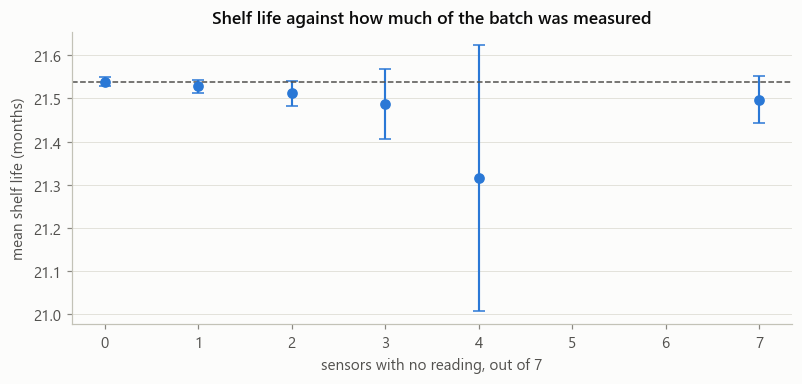

correlation between gap count and shelf life: -0.0047


,batches,mean,sd,sem,vs 0 gaps,sigmas
n_missing,,,,,,
0,151958,21.538,2.043,0.005,0.000,0.000
1,80685,21.528,2.054,0.007,-0.010,-1.448
2,18625,21.512,2.031,0.015,-0.026,-1.760
3,2396,21.486,2.022,0.041,-0.052,-1.255
4,182,21.315,2.114,0.157,-0.223,-1.422
5,10,20.405,1.265,0.400,-1.133,-2.833
7,5344,21.497,2.027,0.028,-0.041,-1.491


In [18]:
# One sensor at a time said the gaps are indiscriminate. Now ask it of
# the whole batch: does a row with four blanks last a different time
# from a row with none?
g = df.groupby("n_missing")["stability_months"]
by_gap = pd.DataFrame({"batches": g.size(), "mean": g.mean(),
                       "sd": g.std()})
by_gap["sem"] = by_gap["sd"] / np.sqrt(by_gap["batches"])
by_gap["vs 0 gaps"] = by_gap["mean"] - by_gap.loc[0, "mean"]
by_gap["sigmas"] = by_gap["vs 0 gaps"] / by_gap["sem"]

big = by_gap[by_gap["batches"] >= 100]
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.errorbar(big.index, big["mean"], yerr=1.96 * big["sem"], fmt="o",
            color=BLUE, capsize=4, lw=1.4, markersize=6)
ax.axhline(by_gap.loc[0, "mean"], color=INK2, lw=1, ls="--")
ax.grid(False); ax.grid(True, axis="y"); ax.set_axisbelow(True)
ax.set_xlabel("sensors with no reading, out of 7")
ax.set_ylabel("mean shelf life (months)")
ax.set_title("Shelf life against how much of the batch was measured")
plt.tight_layout(); plt.show()

print(f"correlation between gap count and shelf life: "
      f"{df['n_missing'].corr(df['stability_months']):+.4f}")
by_gap.round(3)

Flat. A batch with all seven sensors blank averages **21.50 months**
against **21.54** for a fully measured one — a gap of four hundredths, and
every count sits within about 1.8 standard errors of the line. The correlation
between the number of gaps and shelf life is **-0.005**.

That settles two things at once.

**The gaps do not know the answer.** Whatever makes a sensor drop out has
nothing to do with how long the product will last.

It is worth being careful about what that buys us, because it is tempting to
read it as support for leaving the gaps alone. It is not. Had missingness been
related to the outcome, filling it in would have destroyed a real signal and
the case for leaving it would be strong. It is unrelated, so filling in would
not have biased anything either — this check clears the ground rather than
settling the argument. The decision comes later, from measuring both
preparations against each other.

**But the outcome is no easier to predict.** Look at the `sd` column: the
spread of shelf life is the same in every group, about 2.03 months. The product
is exactly as variable when we cannot see it as when we can. What changes is
*our* position, not the process: with no readings there is nothing left to
predict from except the reactor's own typical level.

So `n_missing` earns its place as a feature, but not for the reason one might
assume. It does not help place the centre of the prediction. It tells the model
**how much of the picture it is missing**, which is what a variance head needs
in order to widen its interval honestly rather than pretend.

(The one row to distrust is five gaps: ten batches, so its bar is meaningless.
It is kept in the table and left out of the chart.)

## 4. Timeline

Shelf life is about degradation over time, and any change in the process has to
be located in time to be actionable. The timestamp column arrived as text, so
before parsing it, let us see how many shapes it comes in.

In [19]:
shapes = (df["event_timestamp"].str.replace(r"\d", "D", regex=True)
          .value_counts())
shapes.to_frame("rows")

,rows
event_timestamp,
DDDD-DD-DD DD:DD:DD,234093
DD/DD/DDDD,13024
"May DD, DDDD",4118
"Apr DD, DDDD",4085
"Jun DD, DDDD",3880


Three formats in one column. The first is unambiguous and the third names its
month in words, so neither can be misread. `DD/DD/DDDD` is the problem:
`05/06/2023` is 5 June to a European reader and 6 May to an American one, and
whichever way a parser guesses, it will not complain.

We can settle it with arithmetic. If the first field ever exceeds 12, it cannot
be a month.

In [20]:
slash = df["event_timestamp"].str.match(r"^\d{2}/\d{2}/\d{4}$").fillna(False)
first = df.loc[slash, "event_timestamp"].str[:2].astype(int)

print(f"rows in DD/DD/DDDD form: {slash.sum():,}")
print(f"  first field > 12     : {(first > 12).sum():,}")
print(f"  both fields <= 12    : {(first <= 12).sum():,}")

rows in DD/DD/DDDD form: 13,024
  first field > 12     : 7,815
  both fields <= 12    : 5,209


7,815 rows have a first field above 12, and there is no sixteenth month. The
file is European `DD/MM/YYYY`, and the remaining 5,209 rows follow the same
convention as the rest of their own column.

That leaves the interesting question: what does it actually cost to let a parser
guess instead of telling it?

In [21]:
guessed = pd.to_datetime(df.loc[slash, "event_timestamp"],
                         format="mixed", errors="coerce")
declared = pd.to_datetime(df.loc[slash, "event_timestamp"],
                          format="%d/%m/%Y", errors="coerce")

moved = int((guessed != declared).sum())
off_season = int(guessed.dt.month.isin([1, 2, 3, 7, 8, 9,
                                        10, 11, 12]).sum())
print(f"rows the guess relocates : {moved:,}")
print(f"  into an idle month     : {off_season:,}")
print(f"  wrong day, right month : {moved - off_season:,}")

rows the guess relocates : 4,790
  into an idle month     : 3,938
  wrong day, right month : 852


The guess gets 7,815 of them right by luck, because their month field is
impossible. It then moves 4,790 of the others. Most land in months where this
plant produced nothing, which at least shows up if somebody plots the calendar.
But **852 stay inside the real production window with the wrong day**, and
nothing will ever catch those.

So we parse each format explicitly and never let the parser choose.

In [22]:
FORMATS = ["%Y-%m-%d %H:%M:%S", "%d/%m/%Y", "%b %d, %Y"]

ts = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
for fmt in FORMATS:
    todo = ts.isna()
    parsed = pd.to_datetime(df.loc[todo, "event_timestamp"], format=fmt,
                            errors="coerce").dropna()
    ts.loc[parsed.index] = parsed

df["ts"] = ts
df["date"] = ts.dt.normalize()
# The two short formats carry no clock, so those rows sit at midnight.
df["has_time"] = (df["event_timestamp"]
                  .str.match(r"^\d{4}-\d{2}-\d{2} ").fillna(False))

print(f"unparsed          : {ts.isna().sum()}")
print(f"without a clock   : {(~df['has_time']).sum():,}")
print(f"period covered    : {ts.min():%d %b %Y}  to  {ts.max():%d %b %Y}")

unparsed          : 0
without a clock   : 25,107
period covered    : 01 Apr 2023  to  29 Jun 2023


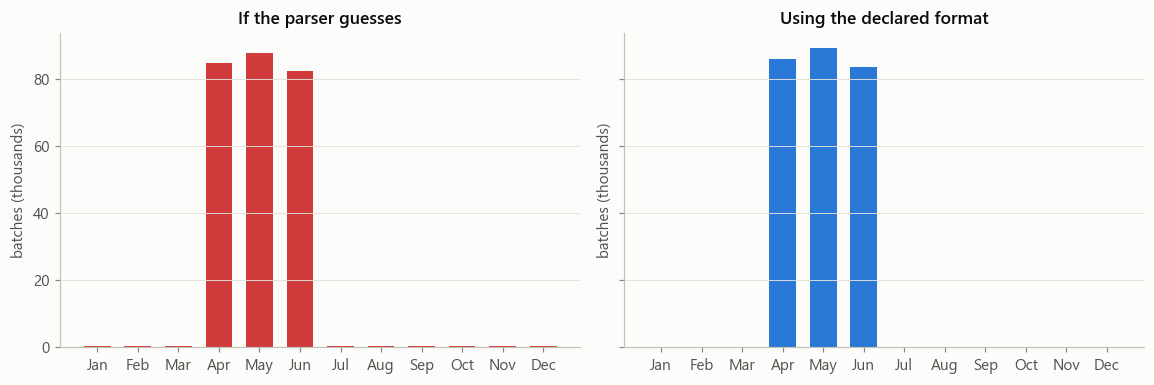

In [23]:
names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
naive = pd.to_datetime(df["event_timestamp"], format="mixed",
                       errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.6), sharey=True)
for ax, series, title, color in [
    (axes[0], naive, "If the parser guesses", RED),
    (axes[1], df["ts"], "Using the declared format", BLUE),
]:
    counts = (series.dt.month.value_counts()
              .reindex(range(1, 13), fill_value=0))
    ax.bar(names, counts.values / 1000, color=color, width=0.66)
    ax.set_title(title)
    ax.set_ylabel("batches (thousands)")
plt.tight_layout(); plt.show()

Nine months of production that never happened, on the left. The real run is
three months, April to June 2023.

One side effect to remember: 25,107 rows came from the two short formats and
therefore have no time of day. Any analysis by shift or hour has to exclude
them, which is what the `has_time` flag is for.

## 5. Correlations and data leakage

The data is now trustworthy. Before looking for causes, it is worth checking
which columns can legitimately be used — both because some may be redundant and
because in production a model only gets what exists at the moment the batch
finishes.

The standard first move is to correlate everything against everything. 

The two derived columns are labels, so they need encoding first — grade has a
natural order, and the flag is boolean. Spearman handles both, and it does not
assume the relationships are straight lines.

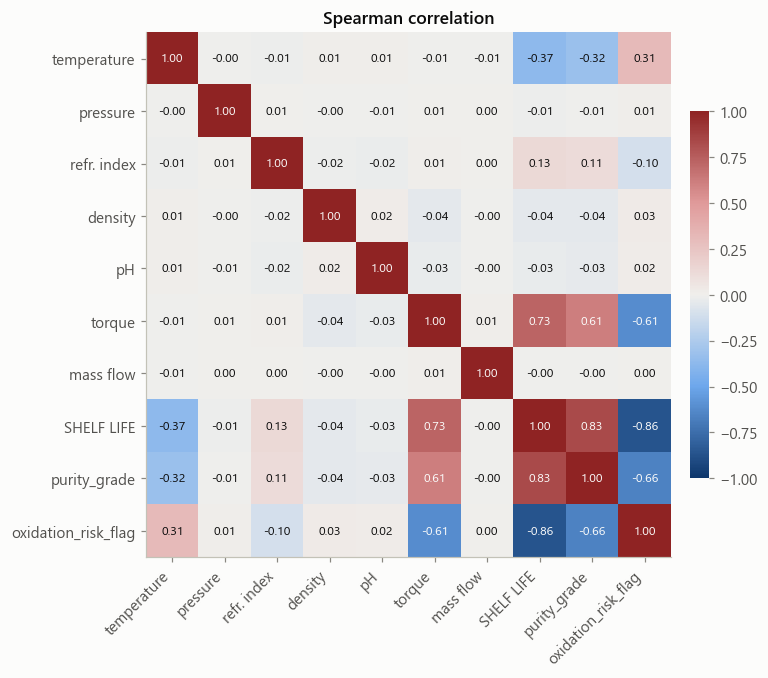

In [ ]:
enc = df.copy()
enc["purity_grade"] = enc["purity_grade"].map(
    {"Technical Grade": 0, "Industrial Grade": 1, "Perfumery Grade": 2})
enc["oxidation_risk_flag"] = enc["oxidation_risk_flag"].astype(int)

COLS = SENSORS + ["stability_months", "purity_grade",
                  "oxidation_risk_flag"]
SHORT = {"temp_c": "temperature", "vessel_pressure_bar": "pressure",
         "refractive_index": "refr. index", "density_g_cm3": "density",
         "ph_level": "pH", "mixing_torque_nm": "torque",
         "mass_flow_rate_kg_h": "mass flow",
         "stability_months": "SHELF LIFE"}

M = (enc[COLS].corr(method="spearman")
     .rename(index=SHORT, columns=SHORT))

# Diverging scale: two opposite hues with a neutral middle, so zero
# reads as "nothing" rather than as a colour.
diverging = LinearSegmentedColormap.from_list(
    "corr", ["#0d366b", "#6da7ec", "#f0efec", "#e09a9a", "#8f2323"])

fig, ax = plt.subplots(figsize=(7.4, 6.2))
im = ax.imshow(M.values, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(M)), M.columns, rotation=45, ha="right")
ax.set_yticks(range(len(M)), M.index)
ax.grid(False)
for i in range(len(M)):
    for j in range(len(M)):
        v = M.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color=SURF if abs(v) > 0.6 else INK)
cb = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
cb.outline.set_visible(False)
ax.set_title("Spearman correlation")
plt.tight_layout(); plt.show()

Three readings, in order of how much they matter.

**The sensor block is empty.** Off the diagonal, no pair of sensors exceeds
|r| = 0.04 and the average is 0.01. Nothing is redundant and there is no
collinearity to worry about. 

**The target row splits cleanly.** Torque at +0.73 and temperature at −0.37,
then a cliff to refractive index at 0.13 and essentially zero for pressure,
density, pH and mass flow.


In [25]:
print(df.groupby("purity_grade")["stability_months"]
      .agg(["min", "max"]).round(5).to_string())
print()
print(df.groupby("oxidation_risk_flag")["stability_months"]
      .agg(["min", "max"]).round(5).to_string())

                       min       max
purity_grade                        
Industrial Grade  20.00003  24.99996
Perfumery Grade   25.00012  28.60916
Technical Grade   18.01519  19.99996

                          min       max
oxidation_risk_flag                    
False                21.00003  28.60916
True                 18.01519  20.99995


The groups do not overlap at all, and they break at 20, 25 and 21 — round
numbers, not the ragged boundaries a real measurement would give. If these are
simple thresholds on the target we should be able to rebuild both columns from
it exactly.

In [26]:
y = df["stability_months"]
grade = np.select([y < 20, y < 25],
                  ["Technical Grade", "Industrial Grade"],
                  default="Perfumery Grade")

print(f"purity_grade        mismatches: "
      f"{(grade != df['purity_grade']).sum():,} of {len(df):,}")
print(f"oxidation_risk_flag mismatches: "
      f"{((y < 21) != df['oxidation_risk_flag']).sum():,} of {len(df):,}")

purity_grade        mismatches: 0 of 259,200
oxidation_risk_flag mismatches: 0 of 259,200


Zero mismatches on 259,200 rows. These are not predictors, they are the answer
relabelled.

It is worth putting a number on what using them would buy, because the number is
not the one people expect. Between them the two columns cut shelf life into four
bands, so we can measure exactly how much of the target they pin down — no model
needed, just the variance inside each band.

In [27]:
bands = df.groupby(["purity_grade", "oxidation_risk_flag"])[
    "stability_months"].agg(["count", "min", "max"])
bands["width"] = (bands["max"] - bands["min"]).round(3)

within = df["stability_months"] - df.groupby(
    ["purity_grade", "oxidation_risk_flag"])[
    "stability_months"].transform("mean")

print(f"shelf-life spread, unconditional      : "
      f"{df['stability_months'].std():.3f} months")
print(f"shelf-life spread, inside a band      : {within.std():.3f} months")
print(f"variance the two columns explain alone: "
      f"{1 - within.var() / df['stability_months'].var():.1%}")
bands.round(3)

shelf-life spread, unconditional      : 2.045 months
shelf-life spread, inside a band      : 0.830 months
variance the two columns explain alone: 83.5%


count     min     max  width
purity_grade     oxidation_risk_flag                               
Industrial Grade False                122683  21.000  25.000  4.000
                 True                  49769  20.000  21.000  1.000
Perfumery Grade  False                 17500  25.000  28.609  3.609
Technical Grade  True                  69248  18.015  20.000  1.985

**83.5% of the variance, from two columns that contain no process information at
all.** For comparison, everything legitimate we have — seven sensors plus plant
and reactor — will get us to roughly 78% in the next phase.

And that is the trap. A model using these does not return a suspicious 0.999 that
any reviewer would stop and question. It returns a plausible, publishable number,
slightly better than the honest model, and it is worthless in the plant: at the
moment a batch finishes neither column exists. Both are computed from the lab
result we are trying to anticipate, months later.

Their proper use is the other way round: derive them **from** a prediction, to
turn "20.4 months" into "Industrial Grade, oxidation risk" for a business
reader.

Now the label columns. Ten reactor IDs across five plants — but do they mean the
same machine everywhere?

In [28]:
df["reactor"] = df["production_line_id"].str.replace(
    "Fragrance-Synthesis-Reactor-", "R", regex=False)
pd.crosstab(df["reactor"], df["plant_location"])

plant_location,Plant-01,Plant-02,Plant-03,Plant-04,Plant-05
reactor,,,,,
R01,5598,6180,5753,5771,5753
R02,6140,6341,6425,6088,6452
R03,6122,7296,6486,6404,6463
R04,7070,7459,7116,7029,7057
R05,6950,7864,7537,7172,7428
R06,7015,0,7813,7426,7770
R07,7658,0,7693,7738,7812
R08,7840,0,0,8230,0
R09,8104,0,0,0,0


They do not. The same IDs reappear at several sites, so these are reactor
*models* or bay positions replicated across plants, not ten unique machines.
R01 to R05 exist everywhere; R09 and R10 only at Plant-01.

That makes the real unit of analysis the pair **plant × reactor**, and there are
37 of those rather than 10. Treating the ID on its own would average four
healthy machines together with any unhealthy one that shares its number.

`plant_country`, meanwhile, adds nothing at all.

In [29]:
df["unit"] = df["plant_location"] + " / " + df["reactor"]
print(f"real units: {df['unit'].nunique()}")

if df.groupby("plant_location")["plant_country"].nunique().eq(1).all():
    print("plant_country is 1:1 with plant_location - dropping it")
    df = df.drop(columns=["plant_country"])

LEAKY = ["purity_grade", "oxidation_risk_flag"]
FEATURES = (SENSORS + [f"missing_{s}" for s in SENSORS]
            + ["n_missing", "plant_location", "reactor"])
assert not set(FEATURES) & set(LEAKY)
print(f"{len(FEATURES)} usable features, {len(LEAKY)} excluded as leakage")

real units: 37
plant_country is 1:1 with plant_location - dropping it
17 usable features, 2 excluded as leakage


One last check before moving on. That correlation matrix drove two decisions, so
it is fair to ask whether cleaning the sensors actually changed it — or whether
we could have read the raw file and saved the trouble.

In [30]:
pd.DataFrame({
    "before cleaning": raw_sensors.corrwith(df["stability_months"]),
    "after cleaning": df[SENSORS].corrwith(df["stability_months"]),
}).assign(change=lambda t: t["after cleaning"] - t["before cleaning"]) \
  .sort_values("change", key=abs, ascending=False).round(4)

,before cleaning,after cleaning,change
temp_c,-0.2124,-0.3798,-0.1674
density_g_cm3,-0.0129,-0.0429,-0.0300
vessel_pressure_bar,0.0011,-0.0102,-0.0113
ph_level,-0.0274,-0.0300,-0.0026
refractive_index,0.1299,0.1299,0.0000
mixing_torque_nm,0.6871,0.6871,0.0000
mass_flow_rate_kg_h,-0.0004,-0.0004,0.0000


It mattered for one sensor in particular. **Temperature reads −0.21 on the raw
column and −0.38 once the failure codes are out** — the codes were hiding almost
half of the second-strongest effect in the dataset. 

## 6. Following the signal

Torque and temperature are the two sensors that move the outcome. Correlation
compresses that into one number, so let us see the size of the effect instead:
how much shelf life differs between the lowest and highest decile of each
sensor.

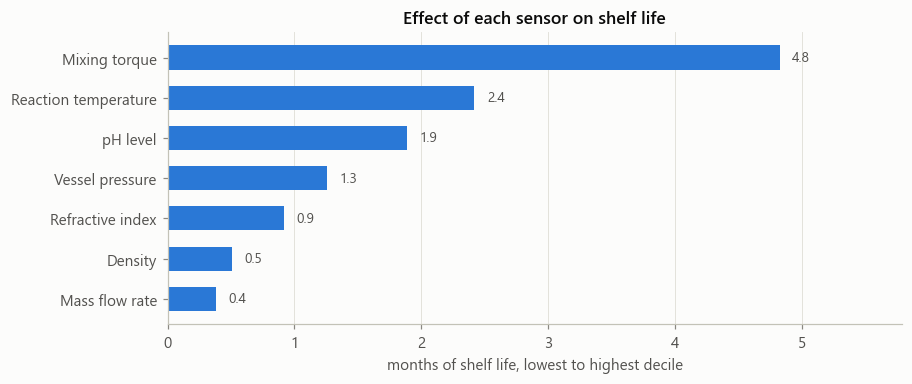

In [31]:
LABELS = {"temp_c": "Reaction temperature", "ph_level": "pH level",
          "vessel_pressure_bar": "Vessel pressure",
          "refractive_index": "Refractive index",
          "density_g_cm3": "Density", "mixing_torque_nm": "Mixing torque",
          "mass_flow_rate_kg_h": "Mass flow rate"}

swing = {}
for s in SENSORS:
    d = df[[s, "stability_months"]].dropna()
    means = d.groupby(pd.qcut(d[s], 10, duplicates="drop"),
                      observed=True)["stability_months"].mean()
    swing[LABELS[s]] = means.max() - means.min()
swing = pd.Series(swing).sort_values()

fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.barh(swing.index, swing.values, color=BLUE, height=0.6)
for i, v in enumerate(swing.values):
    ax.text(v + 0.1, i, f"{v:.1f}", va="center", fontsize=9, color=INK2)
ax.grid(False); ax.grid(True, axis="x"); ax.set_axisbelow(True)
ax.set_xlim(0, swing.max() * 1.2)
ax.set_xlabel("months of shelf life, lowest to highest decile")
ax.set_title("Effect of each sensor on shelf life")
plt.tight_layout(); plt.show()

Mixing torque moves shelf life by more than five months across its range;
temperature by about 2.7 in the opposite direction. The other four are flat.

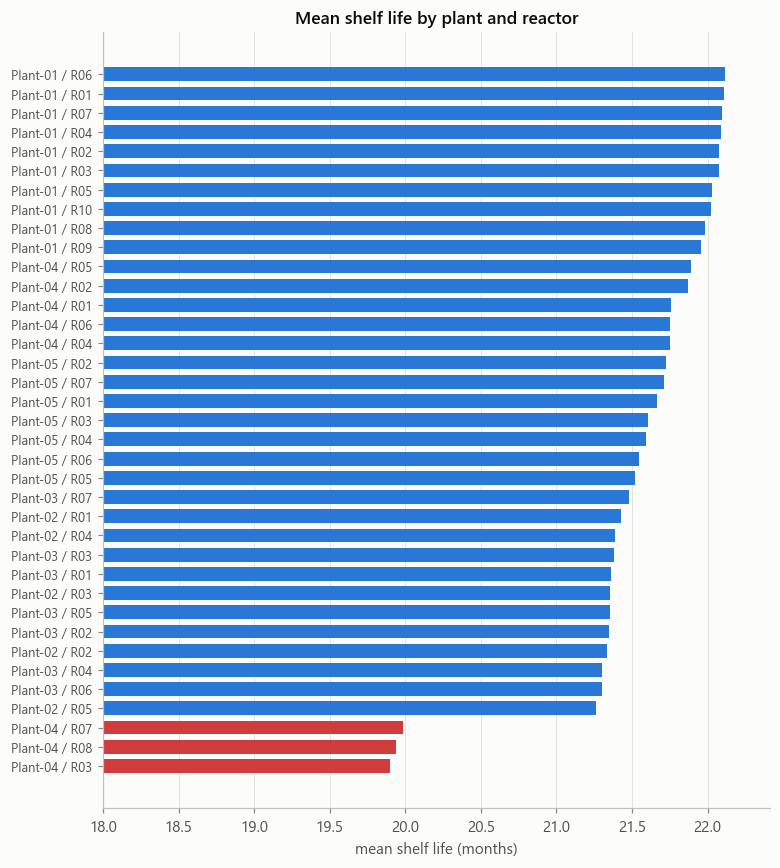

,mean shelf life
unit,
Plant-04 / R03,19.90
Plant-04 / R08,19.94
Plant-04 / R07,19.98
Plant-02 / R05,21.26
Plant-03 / R06,21.30


In [32]:
by_unit = (df.groupby("unit")["stability_months"].mean()
           .sort_values())
worst = by_unit.head(3).index.tolist()

fig, ax = plt.subplots(figsize=(7.2, 8.0))
ax.barh(by_unit.index, by_unit.values,
        color=[RED if u in worst else BLUE for u in by_unit.index],
        height=0.72)
ax.grid(False); ax.grid(True, axis="x"); ax.set_axisbelow(True)
ax.set_xlim(18, by_unit.max() + 0.3)
ax.set_xlabel("mean shelf life (months)")
ax.tick_params(axis="y", labelsize=8.5)
ax.set_title("Mean shelf life by plant and reactor")
plt.tight_layout(); plt.show()

by_unit.head(5).round(2).to_frame("mean shelf life")

Three units sit clearly apart from the other 34, and all three are at the same
plant: **Plant-04, reactors R03, R07 and R08**. The rest of the fleet, Plant-04
included, runs between 21.3 and 22.1 months.

This is where the plant × reactor distinction earns its keep. Those same reactor
models are healthy elsewhere:

In [33]:
(df[df["reactor"].isin(["R03", "R07", "R08"])]
 .pivot_table(index="reactor", columns="plant_location",
              values="stability_months", aggfunc="mean").round(2))

plant_location,Plant-01,Plant-02,Plant-03,Plant-04,Plant-05
reactor,,,,,
R03,22.08,21.35,21.38,19.90,21.61
R07,22.10,NaN,21.48,19.98,21.71
R08,21.98,NaN,NaN,19.94,NaN


R03 averages 21.3 to 22.1 months at four plants and 19.9 at Plant-04. Aggregated
by reactor ID alone the problem would have looked like a mild, fleet-wide
weakness in three reactor models — and the investigation would have gone to the
wrong place.

So it is those three machines, not the design. Next: have they always run this
way, or did something change?

In [34]:
df["faulty"] = df["unit"].isin(worst)

daily = (df.groupby(["date", "unit"], observed=True)
         .agg(torque=("mixing_torque_nm", "mean"),
              shelf=("stability_months", "mean")).reset_index())
daily["faulty"] = daily["unit"].isin(worst)

# Find the change point instead of assuming one: the largest day-to-day
# move in the affected units' mean torque.
bad_daily = daily[daily["faulty"]].groupby("date")["torque"].mean()
change = bad_daily.diff().abs().idxmax()
print(f"largest single-day shift in torque: {change:%d %B %Y}")
print(f"  {bad_daily.shift().loc[change]:.2f} -> "
      f"{bad_daily.loc[change]:.2f} N.m")

largest single-day shift in torque: 08 May 2023
  12.05 -> 10.79 N.m


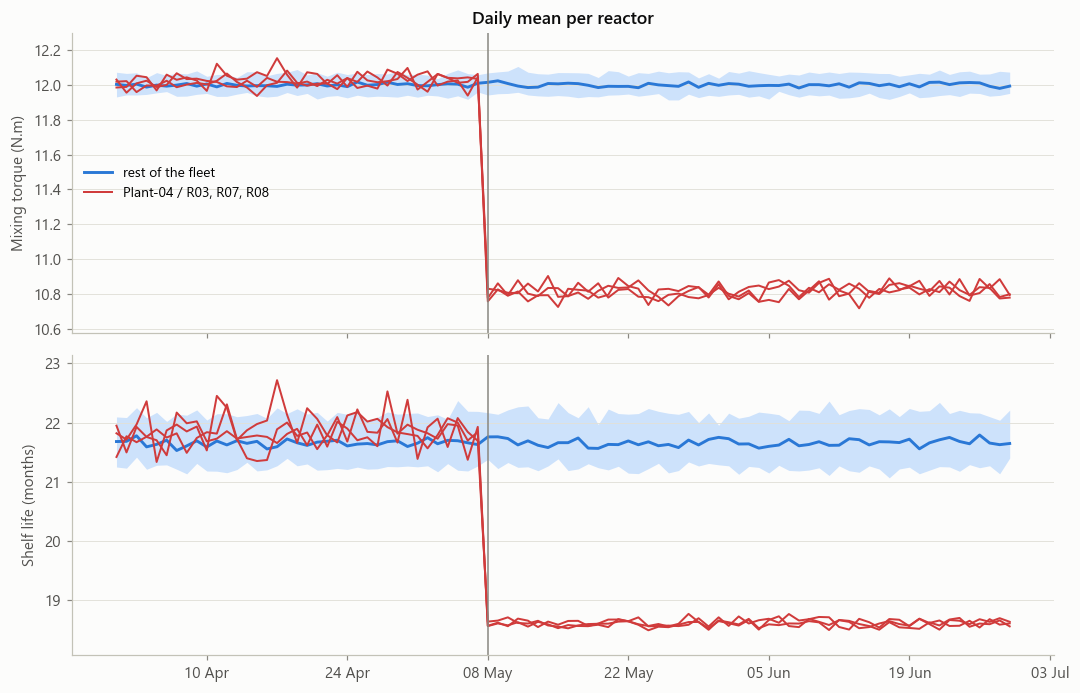

In [35]:
healthy = daily[~daily["faulty"]]
band = healthy.groupby("date").agg(
    t_lo=("torque", lambda s: s.quantile(.10)),
    t_hi=("torque", lambda s: s.quantile(.90)),
    t_md=("torque", "median"),
    s_lo=("shelf", lambda s: s.quantile(.10)),
    s_hi=("shelf", lambda s: s.quantile(.90)),
    s_md=("shelf", "median")).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(10.0, 6.4), sharex=True)
for ax, col, lo, hi, mid, label in [
    (axes[0], "torque", "t_lo", "t_hi", "t_md", "Mixing torque (N.m)"),
    (axes[1], "shelf", "s_lo", "s_hi", "s_md", "Shelf life (months)"),
]:
    ax.fill_between(band["date"], band[lo], band[hi], color=BAND, lw=0)
    ax.plot(band["date"], band[mid], color=BLUE,
            label="rest of the fleet")
    for i, (_, g) in enumerate(daily[daily["faulty"]].groupby("unit")):
        ax.plot(g["date"], g[col], color=RED, lw=1.3,
                label="Plant-04 / R03, R07, R08" if i == 0 else None)
    ax.axvline(change, color=MUTED, lw=1.0)
    ax.set_ylabel(label)
    ax.margins(y=0.10)

axes[0].set_title("Daily mean per reactor")
axes[0].legend(loc="center left")
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0,
                                                      interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout(); plt.show()

In [36]:
period = np.where(df["ts"] < change, "before", "after")
group = np.where(df["faulty"], "Plant-04 R03/R07/R08", "rest of fleet")
(df.assign(period=period, group=group)
   .pivot_table(index="group", columns="period",
                values=["mixing_torque_nm", "stability_months"],
                aggfunc="mean")
   .round(3)[[("mixing_torque_nm", "before"), ("mixing_torque_nm", "after"),
              ("stability_months", "before"), ("stability_months", "after")]])

mixing_torque_nm         stability_months        
period                         before   after           before   after
group                                                                 
Plant-04 R03/R07/R08           12.022  10.818           21.846  18.608
rest of fleet                  12.001  12.000           21.679  21.684

A step, not a drift. On **8 May 2023** all three units drop from about 12.02 to
10.82 N·m overnight and stay there for the remaining seven weeks. Shelf life on
those units falls from 21.85 to 18.61 months, a loss of **3.24 months**. The
other 34 units do not move at all: 21.679 before, 21.684 after.

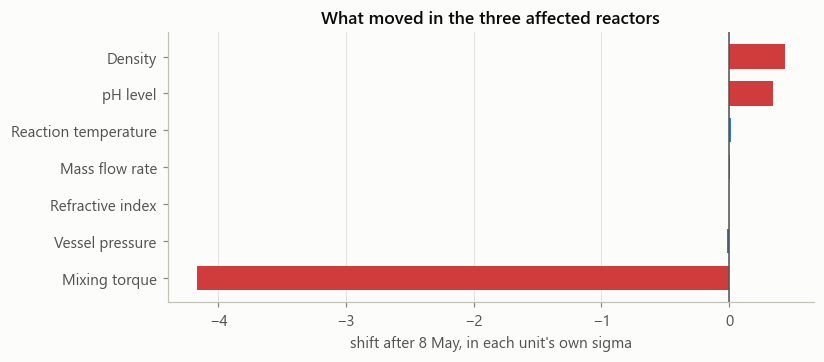

,faulty units,healthy mean,healthy sd,times the noise
Mixing torque,-4.166,-0.003,0.027,151.573
Density,0.433,-0.002,0.025,17.243
pH level,0.341,0.005,0.023,15.096
Vessel pressure,-0.016,0.001,0.019,0.821
Reaction temperature,0.013,-0.001,0.022,0.604
Mass flow rate,0.005,-0.003,0.024,0.225
Refractive index,-0.000,-0.002,0.028,0.003


In [37]:
# Each sensor has its own units, so a shift is only comparable once it
# is expressed in that sensor's own spread. The 34 healthy units, split
# on the same date, say how large an ordinary shift looks.
def shift_in_sigma(g):
    pre, post = g[g["ts"] < change], g[g["ts"] >= change]
    return pd.Series({s: (post[s].mean() - pre[s].mean()) / pre[s].std()
                      for s in SENSORS})


moved = df.groupby(["faulty", "unit"], observed=True).apply(shift_in_sigma)
step = pd.DataFrame({"faulty units": moved.loc[True].mean(),
                     "healthy mean": moved.loc[False].mean(),
                     "healthy sd": moved.loc[False].std()})
step["times the noise"] = step["faulty units"].abs() / step["healthy sd"]

o = step.sort_values("faulty units")
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.barh([LABELS[s] for s in o.index], o["faulty units"], height=0.66,
        color=[RED if abs(v) > 0.2 else BLUE for v in o["faulty units"]])
ax.axvline(0, color=INK2, lw=1)
ax.grid(False); ax.grid(True, axis="x"); ax.set_axisbelow(True)
ax.set_xlabel("shift after 8 May, in each unit's own sigma")
ax.set_title("What moved in the three affected reactors")
plt.tight_layout(); plt.show()

step.rename(index=LABELS).round(3).sort_values(
    "times the noise", ascending=False)

Torque was not alone. **Density rose 0.43 sigma and pH 0.34 sigma** on the same
day, in the same three reactors, while the other four sensors did not move at
all. 

So the question for the plant is a specific one: what was delivered to Plant-04
on 8 May, and which reactors was it charged to.

Plant-04 it is the only site
producing sensor failure codes, and it hosts the three reactors that lost torque.
Before reporting either, we should know whether that is one problem or two.

In [38]:
codes_p4 = df.loc[df["plant_location"] == "Plant-04"].assign(
    coded=has_code[df["plant_location"] == "Plant-04"])

print("code rate by reactor, Plant-04 (%):")
print((codes_p4.groupby("reactor")["coded"].mean() * 100)
      .round(2).to_string())
print("\ncode rate by month, Plant-04 (%):")
print((codes_p4.groupby(codes_p4["ts"].dt.month)["coded"].mean() * 100)
      .round(2).to_string())

code rate by reactor, Plant-04 (%):
reactor
R01    3.43
R02    3.99
R03    3.62
R04    3.91
R05    3.95
R06    3.93
R07    4.02
R08    3.67

code rate by month, Plant-04 (%):
ts
4    3.93
5    3.65
6    3.90


Two problems, not one. The codes appear on **all eight** Plant-04 reactors at
much the same rate, including the five that never lost torque, and they run at a
steady rate through April, May and June — so they were already there a month
before the torque step and they never changed.

In [39]:
oos = []
for s in SENSORS:
    lo, hi = SPEC["temp_value" if s == "temp_c" else s]
    col = df[s]
    oos.append({"sensor": LABELS[s], "spec": f"{lo} - {hi}",
                "min": round(col.min(), 3), "max": round(col.max(), 3),
                "out of spec %": round(((col < lo) | (col > hi)).mean()
                                       * 100, 2)})
pd.DataFrame(oos).set_index("sensor")

,spec,min,max,out of spec %
sensor,,,,
Reaction temperature,75 - 100,78.956,93.126,0.00
Vessel pressure,2 - 3,1.989,2.620,0.20
Refractive index,1.43 - 1.49,1.437,1.484,0.00
Density,0.8 - 0.9,0.837,0.886,0.00
pH level,5.0 - 6.0,4.945,6.111,2.95
Mixing torque,9 - 12.5,10.035,12.564,1.49
Mass flow rate,380 - 520,383.250,521.925,0.18


Torque is the only sensor with a meaningful breach rate, 1.49%, and those are
marginal overshoots at the **top** of the range — high torque, in healthy units.
Temperature, refractive index and density never leave spec at all.

The faulty units settled at 10.82 N·m. The declared band is 9 to 12.5, so its
midpoint is 10.75: the fault parked itself almost exactly in the centre of
specification. Not a high excursion, not a low one.

**No limit alarm could have fired on it**, for the whole 53 days.

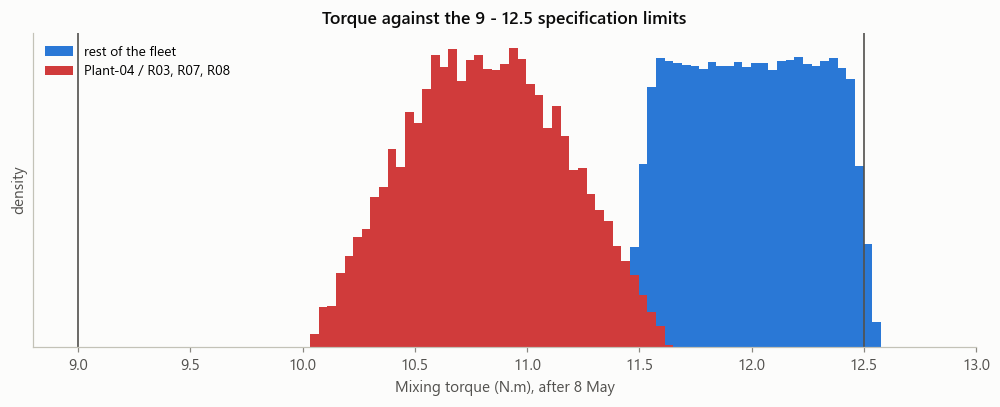

In [40]:
post = df[(df["ts"] >= change) & df["mixing_torque_nm"].notna()]
lo, hi = SPEC["mixing_torque_nm"]

fig, ax = plt.subplots(figsize=(9.2, 3.8))
bins = np.linspace(8.8, 13.0, 110)
ax.hist(post.loc[~post["faulty"], "mixing_torque_nm"], bins=bins,
        density=True, color=BLUE, label="rest of the fleet")
ax.hist(post.loc[post["faulty"], "mixing_torque_nm"], bins=bins,
        density=True, color=RED, label="Plant-04 / R03, R07, R08")
for x in (lo, hi):
    ax.axvline(x, color=INK2, lw=1.1)
ax.set_xlim(8.8, 13.0)
ax.set_yticks([]); ax.set_ylabel("density")
ax.set_xlabel("Mixing torque (N.m), after 8 May")
ax.legend(loc="upper left")
ax.set_title("Torque against the 9 - 12.5 specification limits")
plt.tight_layout(); plt.show()

Both populations sit well inside the limits. The two distributions barely
overlap each other, yet neither touches a boundary — which is precisely why a
limit check saw nothing.

Compare each unit against **its own** history instead, and the picture inverts.

In [41]:
pre = df[(df["ts"] < change) & df["mixing_torque_nm"].notna()]
base = pre.groupby("unit")["mixing_torque_nm"].agg(["mean", "std"])
now = post.groupby("unit")["mixing_torque_nm"].mean()

shift = pd.DataFrame({
    "baseline": base["mean"].round(3),
    "after": now.round(3),
    "sigma from baseline": ((now - base["mean"]) / base["std"]).round(1),
}).sort_values("sigma from baseline")

print(f"units beyond -3 sigma: "
      f"{(shift['sigma from baseline'] < -3).sum()} of {len(shift)}\n")
pd.concat([shift.head(4), shift.tail(2)])

units beyond -3 sigma: 3 of 37



,baseline,after,sigma from baseline
unit,,,
Plant-04 / R08,12.017,10.817,-4.2
Plant-04 / R03,12.014,10.808,-4.2
Plant-04 / R07,12.035,10.827,-4.2
Plant-04 / R04,12.025,12.005,-0.1
Plant-01 / R06,12.047,12.065,0.1
Plant-04 / R02,12.018,12.040,0.1


Months of shelf life are the engineer's unit. The business reads product grade,
so it is worth restating the loss that way.

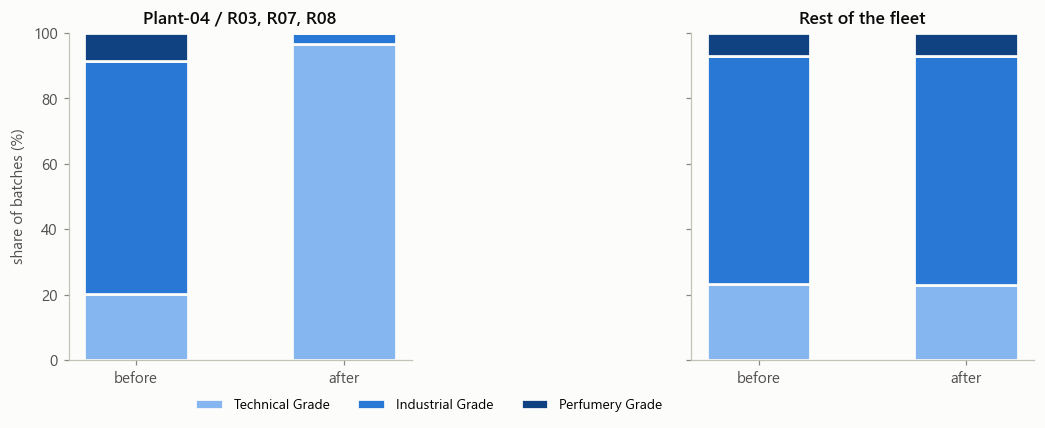

purity_grade,Technical Grade,Industrial Grade,Perfumery Grade
after_change,,,
False,20.1,71.4,8.5
True,96.7,3.3,0.0


In [42]:
GRADES = ["Technical Grade", "Industrial Grade", "Perfumery Grade"]
GRADE_C = ["#86b6ef", "#2a78d6", "#104281"]
df["after_change"] = df["ts"] >= change

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True)
for ax, mask, title in [
    (axes[0], df["faulty"], "Plant-04 / R03, R07, R08"),
    (axes[1], ~df["faulty"], "Rest of the fleet"),
]:
    mix = (pd.crosstab(df.loc[mask, "after_change"],
                       df.loc[mask, "purity_grade"], normalize="index")
           * 100).reindex(columns=GRADES, fill_value=0.0)
    bottom = np.zeros(2)
    for k, g in enumerate(GRADES):
        ax.bar(["before", "after"], mix[g].values, bottom=bottom,
               color=GRADE_C[k], width=0.5, label=g,
               edgecolor=SURF, linewidth=1.8)
        bottom = bottom + mix[g].values
    ax.set_ylim(0, 100); ax.grid(False)
    ax.set_title(title)
axes[0].set_ylabel("share of batches (%)")
axes[0].legend(loc="upper center", bbox_to_anchor=(1.05, -0.08), ncols=3)
plt.tight_layout(); plt.show()

(pd.crosstab(df.loc[df["faulty"], "after_change"],
             df.loc[df["faulty"], "purity_grade"], normalize="index")
 .reindex(columns=GRADES, fill_value=0.0).mul(100).round(1))

In the three affected reactors the mix collapses. **Perfumery Grade, the
highest-value tier, goes from 8.5% of output to zero**, and Technical Grade
rises from 20% to 97%. The rest of the fleet is unchanged, so the damage is
contained to three machines — which is the good news in this.

**13,145 batches** were produced in that state over **53 days**.

In [43]:
print(f"batches from the faulty units after the change: "
      f"{(df['faulty'] & df['after_change']).sum():,}")
print(f"days from the change to the end of the record : "
      f"{(df['ts'].max() - change).days}")

batches from the faulty units after the change: 13,145
days from the change to the end of the record : 52


In [44]:
out = df.rename(columns={"temp_value": "temp_value_raw",
                         "temp_unit": "temp_unit_raw"})

# Guard: every column a model might use must be free of the codes.
CODE_VALUES = [-1.0, 14.0, 210.0, 410.0, 860.0]
model_safe = [c for c in out.select_dtypes("number").columns
              if not c.endswith("_raw")]
dirty = {c: {v: int(out[c].eq(v).sum()) for v in CODE_VALUES
             if out[c].eq(v).any()}
         for c in model_safe}
dirty = {c: v for c, v in dirty.items() if v}
assert not dirty, f"failure codes survive in model-safe columns: {dirty}"

print(f"model-safe numeric columns checked: {len(model_safe)}")
print("raw columns kept for the audit trail, renamed to say so:")
for c in out.columns:
    if c.endswith("_raw"):
        codes = {v: int(out[c].eq(v).sum()) for v in CODE_VALUES
                 if pd.api.types.is_numeric_dtype(out[c])
                 and out[c].eq(v).any()}
        print(f"  {c:20s} {codes if codes else 'no codes'}")

DATA = Path("data")
DATA.mkdir(exist_ok=True)
out.to_parquet(DATA / "fragrance_clean.parquet", index=False)
print(f"\nsaved data/fragrance_clean.parquet: "
      f"{len(out):,} rows x {out.shape[1]} columns")

model-safe numeric columns checked: 9
raw columns kept for the audit trail, renamed to say so:
  temp_value_raw       {210.0: 507, 410.0: 19}
  temp_unit_raw        no codes



saved data/fragrance_clean.parquet: 259,200 rows x 32 columns
